In [29]:
import streamlit as st
import pandas as pd
import joblib

# Load the trained model
# Assuming the 'logistic_regression_model.sav' file is in the same directory as the app.py file
log_reg_model = joblib.load('logistic_regression_model.sav')

# Define the exact columns used during training (X.columns.tolist() from the notebook)
# This list is crucial for aligning new data with the trained model's features
original_df_columns = [
    'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
    'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
    'Warehouse_block_B', 'Warehouse_block_C', 'Warehouse_block_D', 'Warehouse_block_F',
    'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship',
    'Product_importance_low', 'Product_importance_medium', 'Gender_M'
]

def predict_delivery_delay(new_data_df, model, original_df_columns):
    """
    Predicts delivery delay for new data using the trained Logistic Regression model.

    Args:
        new_data_df (pd.DataFrame): DataFrame containing new delivery data.
        model: Trained scikit-learn Logistic Regression model.
        original_df_columns (list): List of columns from the original encoded DataFrame (X).

    Returns:
        pd.Series: Binary predictions (0 for on time, 1 for delayed).
    """
    # Identify categorical columns that were one-hot encoded
    categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

    # Apply one-hot encoding to new data
    new_data_encoded = pd.get_dummies(new_data_df, columns=categorical_cols, drop_first=True)

    # Align columns with the training data columns (X)
    # Add missing columns with zeros
    missing_cols = set(original_df_columns) - set(new_data_encoded.columns)
    for c in missing_cols:
        new_data_encoded[c] = 0

    # Drop extra columns that are not in original_df_columns
    extra_cols = set(new_data_encoded.columns) - set(original_df_columns)
    new_data_encoded = new_data_encoded.drop(columns=list(extra_cols))

    # Ensure the order of columns is the same as in X_train
    new_data_processed = new_data_encoded[original_df_columns]

    # Make predictions
    predictions = model.predict(new_data_processed)
    return pd.Series(predictions, index=new_data_df.index)


# --- Streamlit UI ---
st.set_page_config(page_title="Delivery Delay Prediction App", layout="centered")

st.title("🚚 Delivery Delay Prediction App")
st.markdown("Predict whether a delivery will be delayed (1) or on time (0) based on various factors.")

st.header("Input Delivery Details")

# Input widgets for features
col1, col2 = st.columns(2)

with col1:
    warehouse_block = st.selectbox("Warehouse Block", ['A', 'B', 'C', 'D', 'F'])
    mode_of_shipment = st.selectbox("Mode of Shipment", ['Flight', 'Road', 'Ship'])
    customer_care_calls = st.number_input("Customer Care Calls", min_value=1, max_value=7, value=3)
    customer_rating = st.slider("Customer Rating (1-5)", min_value=1, max_value=5, value=3)

with col2:
    cost_of_the_product = st.number_input("Cost of the Product ($)", min_value=96, max_value=310, value=150)
    prior_purchases = st.number_input("Prior Purchases", min_value=1, max_value=10, value=2)
    product_importance = st.selectbox("Product Importance", ['low', 'medium', 'high'])
    gender = st.radio("Gender", ['F', 'M'])
    discount_offered = st.number_input("Discount Offered (%)", min_value=0, max_value=65, value=10)
    weight_in_gms = st.number_input("Weight in Grams", min_value=1000, max_value=7800, value=4000)


# Create a DataFrame from user inputs
input_data = pd.DataFrame({
    'Warehouse_block': [warehouse_block],
    'Mode_of_Shipment': [mode_of_shipment],
    'Customer_care_calls': [customer_care_calls],
    'Customer_rating': [customer_rating],
    'Cost_of_the_Product': [cost_of_the_product],
    'Prior_purchases': [prior_purchases],
    'Product_importance': [product_importance],
    'Gender': [gender],
    'Discount_offered': [discount_offered],
    'Weight_in_gms': [weight_in_gms]
})


if st.button("Predict Delivery Status"):
    prediction = predict_delivery_delay(input_data, log_reg_model, original_df_columns)
    if prediction.iloc[0] == 1:
        st.error("### ⚠️ Prediction: Delivery is LIKELY to be DELAYED!")
    else:
        st.success("### ✅ Prediction: Delivery is LIKELY to be ON TIME!")

    st.markdown("--- ")
    st.subheader("Input Data for Prediction")
    st.dataframe(input_data)



ModuleNotFoundError: No module named 'streamlit'

2026-09-28 23:05:12.381 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-28 23:05:12.389 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-28 23:05:12.985 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-28 23:05:12.988 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-28 23:05:12.990 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-28 23:05:12.993 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-28 23:05:12.996 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

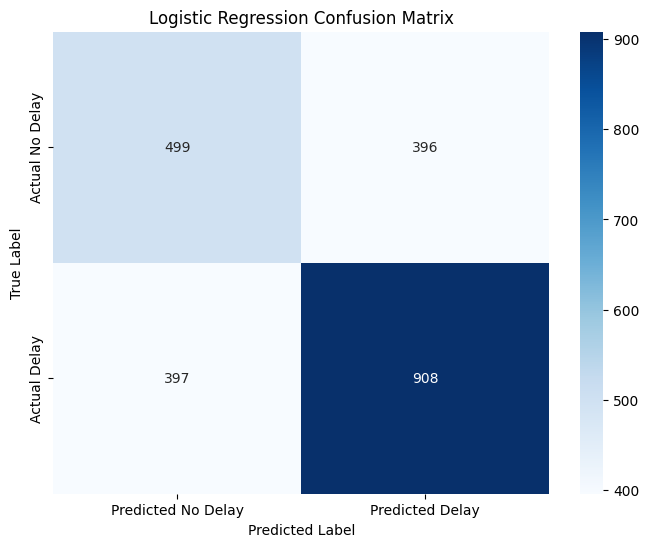

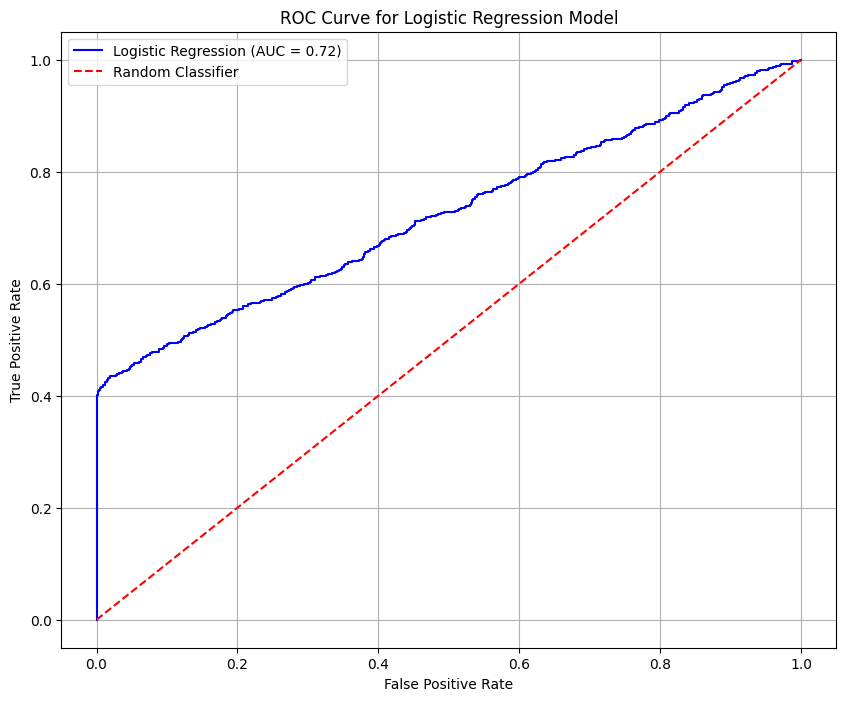

In [57]:
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

st.set_page_config(page_title="Delivery Delay Prediction Project Showcase", layout="wide")

st.title("📦 Delivery Delay Prediction Project")
st.markdown("This application showcases the entire process of building a delivery delay prediction model, from data exploration to an interactive prediction interface.")

# --- 1. Data Loading ---
st.header("1. Data Loading")
@st.cache_data # Cache data loading for performance
def load_data():
    df = pd.read_csv('/content/delivery_data.csv')
    return df

df = load_data()
st.subheader("Raw Data (First 5 Rows)")
st.dataframe(df.head())

# --- 2. Data Exploration ---
st.header("2. Data Exploration")

st.subheader("DataFrame Information")
import io
buffer = io.StringIO()
df.info(buf=buffer)
s = buffer.getvalue()
st.text(s)

st.subheader("Descriptive Statistics")
st.dataframe(df.describe(include='all'))

st.subheader("Missing Values")
st.dataframe(df.isnull().sum())

st.subheader("Duplicate Rows")
st.write(f"Number of duplicate rows: {df.duplicated().sum()}")

# --- 3. Data Preprocessing ---
st.header("3. Data Preprocessing")
st.markdown("Categorical variables are converted to numerical using one-hot encoding.")

@st.cache_data
def preprocess_data(data):
    categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
    df_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
    X = df_encoded.drop(columns=['ID', 'Reached.on.Time_Y.N'])
    y = df_encoded['Reached.on.Time_Y.N']
    return X, y, df_encoded

X, y, df_encoded = preprocess_data(df)

st.subheader("Encoded Data (First 5 Rows)")
st.dataframe(df_encoded.head())

st.subheader("Features Used for Training")
st.write(X.columns.tolist())

# --- 4. Model Training & Evaluation (using pre-trained model) ---
st.header("4. Model Performance (Logistic Regression)")

# Load the trained model
@st.cache_resource # Cache the model loading
def load_model():
    return joblib.load('logistic_regression_model.sav')

log_reg_model = load_model()

# Split data for evaluation (consistent with training split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_pred_proba_log_reg)
auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)

st.subheader("Performance Metrics")
metric_cols = st.columns(4)
metric_cols[0].metric("Accuracy", f"{accuracy_log_reg:.4f}")
metric_cols[1].metric("Precision", f"{precision_log_reg:.4f}")
metric_cols[2].metric("Recall", f"{recall_log_reg:.4f}")
metric_cols[3].metric("F1-Score", f"{f1_log_reg:.4f}")

st.subheader("Confusion Matrix")
fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Delay', 'Predicted Delay'],
            yticklabels=['Actual No Delay', 'Actual Delay'], ax=ax_cm)
ax_cm.set_title('Logistic Regression Confusion Matrix')
ax_cm.set_xlabel('Predicted Label')
ax_cm.set_ylabel('True Label')
st.pyplot(fig_cm)

st.subheader("ROC Curve")
fig_roc, ax_roc = plt.subplots(figsize=(10, 8))
ax_roc.plot(fpr_log_reg, tpr_log_reg, color='blue', label=f'Logistic Regression (AUC = {auc_log_reg:.2f})')
ax_roc.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve for Logistic Regression Model')
ax_roc.legend()
ax_roc.grid(True)
st.pyplot(fig_roc)

# --- 5. Interactive Prediction Tool ---
st.header("5. Interactive Prediction Tool")
st.markdown("Enter details below to get a real-time prediction for delivery delay.")

def predict_delivery_delay(new_data_df, model, original_df_columns):
    """
    Predicts delivery delay for new data using the trained Logistic Regression model.
    """
    categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
    new_data_encoded = pd.get_dummies(new_data_df, columns=categorical_cols, drop_first=True)

    missing_cols = set(original_df_columns) - set(new_data_encoded.columns)
    for c in missing_cols:
        new_data_encoded[c] = 0

    extra_cols = set(new_data_encoded.columns) - set(original_df_columns)
    new_data_encoded = new_data_encoded.drop(columns=list(extra_cols))

    new_data_processed = new_data_encoded[original_df_columns]

    predictions = model.predict(new_data_processed)
    return pd.Series(predictions, index=new_data_df.index)

# Input widgets for features
col1_input, col2_input = st.columns(2)

with col1_input:
    warehouse_block = st.selectbox("Warehouse Block", ['A', 'B', 'C', 'D', 'F'], key='warehouse_block_input')
    mode_of_shipment = st.selectbox("Mode of Shipment", ['Flight', 'Road', 'Ship'], key='mode_of_shipment_input')
    customer_care_calls = st.number_input("Customer Care Calls", min_value=1, max_value=7, value=3, key='customer_care_calls_input')
    customer_rating = st.slider("Customer Rating (1-5)", min_value=1, max_value=5, value=3, key='customer_rating_input')

with col2_input:
    cost_of_the_product = st.number_input("Cost of the Product ($)", min_value=96, max_value=310, value=150, key='cost_of_product_input')
    prior_purchases = st.number_input("Prior Purchases", min_value=1, max_value=10, value=2, key='prior_purchases_input')
    product_importance = st.selectbox("Product Importance", ['low', 'medium', 'high'], key='product_importance_input')
    gender = st.radio("Gender", ['F', 'M'], key='gender_input')
    discount_offered = st.number_input("Discount Offered (%)", min_value=0, max_value=65, value=10, key='discount_offered_input')
    weight_in_gms = st.number_input("Weight in Grams", min_value=1000, max_value=7800, value=4000, key='weight_in_gms_input')


# Create a DataFrame from user inputs
input_data = pd.DataFrame({
    'Warehouse_block': [warehouse_block],
    'Mode_of_Shipment': [mode_of_shipment],
    'Customer_care_calls': [customer_care_calls],
    'Customer_rating': [customer_rating],
    'Cost_of_the_Product': [cost_of_the_product],
    'Prior_purchases': [prior_purchases],
    'Product_importance': [product_importance],
    'Gender': [gender],
    'Discount_offered': [discount_offered],
    'Weight_in_gms': [weight_in_gms]
})

# Define the exact columns used during training (X.columns.tolist() from the notebook)
original_df_columns = [
    'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
    'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
    'Warehouse_block_B', 'Warehouse_block_C', 'Warehouse_block_D', 'Warehouse_block_F',
    'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship',
    'Product_importance_low', 'Product_importance_medium', 'Gender_M'
]

if st.button("Predict Delivery Status", key='predict_button'):
    prediction = predict_delivery_delay(input_data, log_reg_model, original_df_columns)
    if prediction.iloc[0] == 1:
        st.error("### ⚠️ Prediction: Delivery is LIKELY to be DELAYED!")
    else:
        st.success("### ✅ Prediction: Delivery is LIKELY to be ON TIME!")

    st.markdown("--- ")
    st.subheader("Input Data for Prediction")
    st.dataframe(input_data)



To save the Streamlit app to a local `app.py` file, you can add `%%writefile app.py` at the very top of the cell containing the Streamlit code (cell `bc524bfc`). Then run that cell to create the file. **Make sure `logistic_regression_model.sav` and `delivery_data.csv` are in the same directory as `app.py` when you run the Streamlit application locally.**

In [58]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

st.set_page_config(page_title="Delivery Delay Prediction Project Showcase", layout="wide")

st.title("📦 Delivery Delay Prediction Project")
st.markdown("This application showcases the entire process of building a delivery delay prediction model, from data exploration to an interactive prediction interface.")

# --- 1. Data Loading ---
st.header("1. Data Loading")
@st.cache_data # Cache data loading for performance
def load_data():
    df = pd.read_csv('/content/delivery_data.csv')
    return df

df = load_data()
st.subheader("Raw Data (First 5 Rows)")
st.dataframe(df.head())

# --- 2. Data Exploration ---
st.header("2. Data Exploration")

st.subheader("DataFrame Information")
import io
buffer = io.StringIO()
df.info(buf=buffer)
s = buffer.getvalue()
st.text(s)

st.subheader("Descriptive Statistics")
st.dataframe(df.describe(include='all'))

st.subheader("Missing Values")
st.dataframe(df.isnull().sum())

st.subheader("Duplicate Rows")
st.write(f"Number of duplicate rows: {df.duplicated().sum()}")

# --- 3. Data Preprocessing ---
st.header("3. Data Preprocessing")
st.markdown("Categorical variables are converted to numerical using one-hot encoding.")

@st.cache_data
def preprocess_data(data):
    categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
    df_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
    X = df_encoded.drop(columns=['ID', 'Reached.on.Time_Y.N'])
    y = df_encoded['Reached.on.Time_Y.N']
    return X, y, df_encoded

X, y, df_encoded = preprocess_data(df)

st.subheader("Encoded Data (First 5 Rows)")
st.dataframe(df_encoded.head())

st.subheader("Features Used for Training")
st.write(X.columns.tolist())

# --- 4. Model Training & Evaluation (using pre-trained model) ---
st.header("4. Model Performance (Logistic Regression)")

# Load the trained model
@st.cache_resource # Cache the model loading
def load_model():
    return joblib.load('logistic_regression_model.sav')

log_reg_model = load_model()

# Split data for evaluation (consistent with training split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_pred_proba_log_reg)
auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)

st.subheader("Performance Metrics")
metric_cols = st.columns(4)
metric_cols[0].metric("Accuracy", f"{accuracy_log_reg:.4f}")
metric_cols[1].metric("Precision", f"{precision_log_reg:.4f}")
metric_cols[2].metric("Recall", f"{recall_log_reg:.4f}")
metric_cols[3].metric("F1-Score", f"{f1_log_reg:.4f}")

st.subheader("Confusion Matrix")
fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Delay', 'Predicted Delay'],
            yticklabels=['Actual No Delay', 'Actual Delay'], ax=ax_cm)
ax_cm.set_title('Logistic Regression Confusion Matrix')
ax_cm.set_xlabel('Predicted Label')
ax_cm.set_ylabel('True Label')
st.pyplot(fig_cm)

st.subheader("ROC Curve")
fig_roc, ax_roc = plt.subplots(figsize=(10, 8))
ax_roc.plot(fpr_log_reg, tpr_log_reg, color='blue', label=f'Logistic Regression (AUC = {auc_log_reg:.2f})')
ax_roc.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve for Logistic Regression Model')
ax_roc.legend()
ax_roc.grid(True)
st.pyplot(fig_roc)

# --- 5. Interactive Prediction Tool ---
st.header("5. Interactive Prediction Tool")
st.markdown("Enter details below to get a real-time prediction for delivery delay.")

def predict_delivery_delay(new_data_df, model, original_df_columns):
    """
    Predicts delivery delay for new data using the trained Logistic Regression model.
    """
    categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
    new_data_encoded = pd.get_dummies(new_data_df, columns=categorical_cols, drop_first=True)

    missing_cols = set(original_df_columns) - set(new_data_encoded.columns)
    for c in missing_cols:
        new_data_encoded[c] = 0

    extra_cols = set(new_data_encoded.columns) - set(original_df_columns)
    new_data_encoded = new_data_encoded.drop(columns=list(extra_cols))

    new_data_processed = new_data_encoded[original_df_columns]

    predictions = model.predict(new_data_processed)
    return pd.Series(predictions, index=new_data_df.index)

# Input widgets for features
col1_input, col2_input = st.columns(2)

with col1_input:
    warehouse_block = st.selectbox("Warehouse Block", ['A', 'B', 'C', 'D', 'F'], key='warehouse_block_input')
    mode_of_shipment = st.selectbox("Mode of Shipment", ['Flight', 'Road', 'Ship'], key='mode_of_shipment_input')
    customer_care_calls = st.number_input("Customer Care Calls", min_value=1, max_value=7, value=3, key='customer_care_calls_input')
    customer_rating = st.slider("Customer Rating (1-5)", min_value=1, max_value=5, value=3, key='customer_rating_input')

with col2_input:
    cost_of_the_product = st.number_input("Cost of the Product ($", min_value=96, max_value=310, value=150, key='cost_of_product_input')
    prior_purchases = st.number_input("Prior Purchases", min_value=1, max_value=10, value=2, key='prior_purchases_input')
    product_importance = st.selectbox("Product Importance", ['low', 'medium', 'high'], key='product_importance_input')
    gender = st.radio("Gender", ['F', 'M'], key='gender_input')
    discount_offered = st.number_input("Discount Offered (%)", min_value=0, max_value=65, value=10, key='discount_offered_input')
    weight_in_gms = st.number_input("Weight in Grams", min_value=1000, max_value=7800, value=4000, key='weight_in_gms_input')


# Create a DataFrame from user inputs
input_data = pd.DataFrame({
    'Warehouse_block': [warehouse_block],
    'Mode_of_Shipment': [mode_of_shipment],
    'Customer_care_calls': [customer_care_calls],
    'Customer_rating': [customer_rating],
    'Cost_of_the_Product': [cost_of_the_product],
    'Prior_purchases': [prior_purchases],
    'Product_importance': [product_importance],
    'Gender': [gender],
    'Discount_offered': [discount_offered],
    'Weight_in_gms': [weight_in_gms]
})

# Define the exact columns used during training (X.columns.tolist() from the notebook)
original_df_columns = [
    'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
    'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
    'Warehouse_block_B', 'Warehouse_block_C', 'Warehouse_block_D', 'Warehouse_block_F',
    'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship',
    'Product_importance_low', 'Product_importance_medium', 'Gender_M'
]

if st.button("Predict Delivery Status", key='predict_button'):
    prediction = predict_delivery_delay(input_data, log_reg_model, original_df_columns)
    if prediction.iloc[0] == 1:
        st.error("### ⚠️ Prediction: Delivery is LIKELY to be DELAYED!")
    else:
        st.success("### ✅ Prediction: Delivery is LIKELY to be ON TIME!")

    st.markdown("--- ")
    st.subheader("Input Data for Prediction")
    st.dataframe(input_data)


Writing app.py


In [ ]:
import pandas as pd

# Load the delivery data
df = pd.read_csv('/content/delivery_data.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

In [56]:
import sys

# Install Streamlit and pandas if not already installed
!{sys.executable} -m pip install streamlit pandas joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 65.6 MB/s eta 0:00:00


In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
# Display information about the DataFrame, including data types and non-null values
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [32]:
# Display descriptive statistics of the DataFrame
print("\nDescriptive Statistics:")
display(df.describe(include='all'))


Descriptive Statistics:


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999,10999,10999.000000,10999.000000,10999.000000,10999.000000,10999,10999,10999.000000,10999.000000,10999.000000
unique,NaN,5,3,NaN,NaN,NaN,NaN,3,2,NaN,NaN,NaN
top,NaN,F,Ship,NaN,NaN,NaN,NaN,low,F,NaN,NaN,NaN
freq,NaN,3666,7462,NaN,NaN,NaN,NaN,5297,5545,NaN,NaN,NaN
mean,5500.00000,NaN,NaN,4.054459,2.990545,210.196836,3.567597,NaN,NaN,13.373216,3634.016729,0.596691
std,3175.28214,NaN,NaN,1.141490,1.413603,48.063272,1.522860,NaN,NaN,16.205527,1635.377251,0.490584
min,1.00000,NaN,NaN,2.000000,1.000000,96.000000,2.000000,NaN,NaN,1.000000,1001.000000,0.000000
25%,2750.50000,NaN,NaN,3.000000,2.000000,169.000000,3.000000,NaN,NaN,4.000000,1839.500000,0.000000
50%,5500.00000,NaN,NaN,4.000000,3.000000,214.000000,3.000000,NaN,NaN,7.000000,4149.000000,1.000000
75%,8249.50000,NaN,NaN,5.000000,4.000000,251.000000,4.000000,NaN,NaN,10.000000,5050.000000,1.000000


In [33]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
ID,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0


In [34]:
# Check for duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Number of duplicate rows:
0


In [35]:
# Convert categorical variables to numerical using one-hot encoding
df_encoded = pd.get_dummies(df, columns=['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender'], drop_first=True)

# Display the first few rows of the encoded DataFrame to verify
print("\nFirst 5 rows of the encoded dataset:")
display(df_encoded.head())


First 5 rows of the encoded dataset:


,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,1,4,2,177,3,44,1233,1,False,False,True,False,False,False,True,False,False
1,2,4,5,216,2,59,3088,1,False,False,False,True,False,False,True,False,True
2,3,2,2,183,4,48,3374,1,False,False,False,False,False,False,True,False,True
3,4,3,3,176,4,10,1177,1,True,False,False,False,False,False,False,True,True
4,5,2,2,184,3,46,2484,1,False,True,False,False,False,False,False,True,False


In [36]:
# Define features (X) and target (y)
X = df_encoded.drop(columns=['ID', 'Reached.on.Time_Y.N'])
y = df_encoded['Reached.on.Time_Y.N']

print(f"\nShape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print("\nFeatures (X) columns:")
print(X.columns.tolist())


Shape of features (X): (10999, 15)
Shape of target (y): (10999,)

Features (X) columns:
['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'Warehouse_block_B', 'Warehouse_block_C', 'Warehouse_block_D', 'Warehouse_block_F', 'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship', 'Product_importance_low', 'Product_importance_medium', 'Gender_M']


In [37]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (8799, 15)
Shape of X_test: (2200, 15)
Shape of y_train: (8799,)
Shape of y_test: (2200,)


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for small datasets and L1/L2 regularization
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

print("\nLogistic Regression Model Performance:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print("Confusion Matrix:\n", conf_matrix_log_reg)


Logistic Regression Model Performance:
Accuracy: 0.6395
Precision: 0.6963
Recall: 0.6958
F1-Score: 0.6961
Confusion Matrix:
 [[499 396]
 [397 908]]


In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Initialize and train the Linear Regression model
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)

# Make continuous predictions on the test set
y_pred_lin_reg_continuous = lin_reg_model.predict(X_test)

# Convert continuous predictions to binary (0 or 1) using a threshold (e.g., 0.5)
y_pred_lin_reg_binary = (y_pred_lin_reg_continuous > 0.5).astype(int)

# Evaluate the model using classification metrics
accuracy_lin_reg = accuracy_score(y_test, y_pred_lin_reg_binary)
precision_lin_reg = precision_score(y_test, y_pred_lin_reg_binary)
recall_lin_reg = recall_score(y_test, y_pred_lin_reg_binary)
f1_lin_reg = f1_score(y_test, y_pred_lin_reg_binary)
conf_matrix_lin_reg = confusion_matrix(y_test, y_pred_lin_reg_binary)

print("\nLinear Regression Model Performance (with 0.5 threshold for binary classification):")
print(f"Accuracy: {accuracy_lin_reg:.4f}")
print(f"Precision: {precision_lin_reg:.4f}")
print(f"Recall: {recall_lin_reg:.4f}")
print(f"F1-Score: {f1_lin_reg:.4f}")
print("Confusion Matrix:\n", conf_matrix_lin_reg)

print("\nNote: Linear Regression is generally not suitable for binary classification tasks because its predictions are continuous and can be outside the [0, 1] range, making direct probability interpretation problematic and requiring an arbitrary threshold for classification. Logistic Regression is designed specifically for binary classification, modeling the probability of the positive class.")


Linear Regression Model Performance (with 0.5 threshold for binary classification):
Accuracy: 0.6473
Precision: 0.7002
Recall: 0.7088
F1-Score: 0.7045
Confusion Matrix:
 [[499 396]
 [380 925]]

Note: Linear Regression is generally not suitable for binary classification tasks because its predictions are continuous and can be outside the [0, 1] range, making direct probability interpretation problematic and requiring an arbitrary threshold for classification. Logistic Regression is designed specifically for binary classification, modeling the probability of the positive class.


In [40]:
def predict_delivery_delay(new_data_df, model, original_df_columns):
    """
    Predicts delivery delay for new data using the trained Logistic Regression model.

    Args:
        new_data_df (pd.DataFrame): DataFrame containing new delivery data.
        model: Trained scikit-learn Logistic Regression model.
        original_df_columns (list): List of columns from the original encoded DataFrame (X).

    Returns:
        pd.Series: Binary predictions (0 for on time, 1 for delayed).
    """
    # Identify categorical columns that were one-hot encoded
    categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

    # Apply one-hot encoding to new data
    new_data_encoded = pd.get_dummies(new_data_df, columns=categorical_cols, drop_first=True)

    # Align columns with the training data columns (X)
    # Add missing columns with zeros
    missing_cols = set(original_df_columns) - set(new_data_encoded.columns)
    for c in missing_cols:
        new_data_encoded[c] = 0

    # Drop extra columns that are not in original_df_columns
    extra_cols = set(new_data_encoded.columns) - set(original_df_columns)
    new_data_encoded = new_data_encoded.drop(columns=list(extra_cols))

    # Ensure the order of columns is the same as in X_train
    new_data_processed = new_data_encoded[original_df_columns]

    # Make predictions
    predictions = model.predict(new_data_processed)
    return pd.Series(predictions, index=new_data_df.index)

print("Predictive tool function `predict_delivery_delay` defined.")

Predictive tool function `predict_delivery_delay` defined.


In [41]:
# Example Usage of the Predictive Tool

# Create some sample new data (ensure it mimics the original data structure before encoding)
# For demonstration, we'll take a few rows from our test set as 'new data'
# and remove the target variable and ID, then reset index.

sample_new_data = df.loc[X_test.index].drop(columns=['ID', 'Reached.on.Time_Y.N']).reset_index(drop=True)

# Display the sample new data
print("\nSample New Data for Prediction:")
display(sample_new_data.head())

# Get predictions using the tool
predictions = predict_delivery_delay(sample_new_data, log_reg_model, X.columns.tolist())

print("\nPredictions for Sample New Data:")
print(predictions.head())

print("\nComparing actual vs predicted for the first 5 samples:")
# Map the original index of X_test to the reset index of sample_new_data for comparison
actual_results = y_test.loc[X_test.index[:5]]

comparison_df = pd.DataFrame({'Actual_Reached.on.Time': actual_results.values, 'Predicted_Reached.on.Time': predictions.head().values}, index=sample_new_data.index[:5])
print(comparison_df)


Sample New Data for Prediction:


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms
0,F,Ship,4,5,216,3,high,M,26,2053
1,A,Road,3,1,220,3,low,F,6,5572
2,F,Flight,3,2,215,4,low,F,3,4042
3,D,Flight,5,1,160,5,low,F,1,4672
4,B,Ship,5,4,229,2,medium,F,44,2419



Predictions for Sample New Data:
0    1
1    0
2    0
3    0
4    1
dtype: int64

Comparing actual vs predicted for the first 5 samples:
   Actual_Reached.on.Time  Predicted_Reached.on.Time
0                       1                          1
1                       1                          0
2                       0                          0
3                       0                          0
4                       1                          1


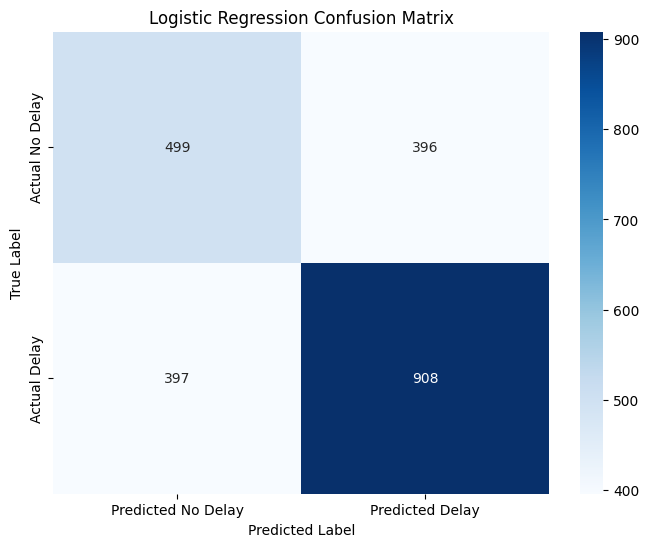

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Confusion Matrix for Logistic Regression
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Delay', 'Predicted Delay'],
            yticklabels=['Actual No Delay', 'Actual Delay'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

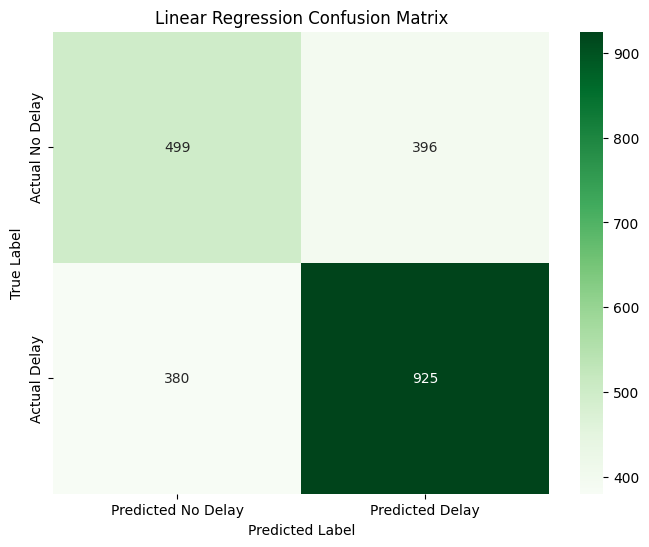

In [43]:
# Visualize Confusion Matrix for Linear Regression
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lin_reg, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted No Delay', 'Predicted Delay'],
            yticklabels=['Actual No Delay', 'Actual Delay'])
plt.title('Linear Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for Logistic Regression
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC for Logistic Regression
fpr_log_reg, tpr_log_reg, thresholds_log_reg = roc_curve(y_test, y_pred_proba_log_reg)
auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)

# Get predicted probabilities for Linear Regression
# For Linear Regression, we use the continuous predictions directly, as they can be interpreted as scores
y_pred_proba_lin_reg = lin_reg_model.predict(X_test)

# Calculate ROC curve and AUC for Linear Regression
fpr_lin_reg, tpr_lin_reg, thresholds_lin_reg = roc_curve(y_test, y_pred_proba_lin_reg)
auc_lin_reg = roc_auc_score(y_test, y_pred_proba_lin_reg)

print(f"\nLogistic Regression AUC: {auc_log_reg:.4f}")
print(f"Linear Regression AUC: {auc_lin_reg:.4f}")


Logistic Regression AUC: 0.7231
Linear Regression AUC: 0.7329


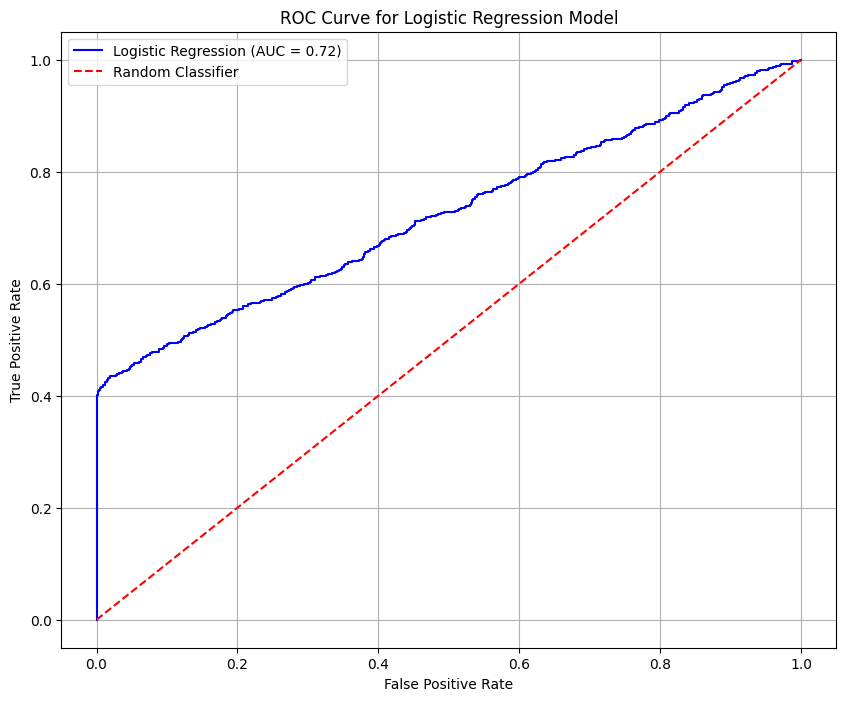

In [45]:
import matplotlib.pyplot as plt

# Plot ROC curves for Logistic Regression only
plt.figure(figsize=(10, 8))
plt.plot(fpr_log_reg, tpr_log_reg, color='blue', label=f'Logistic Regression (AUC = {auc_log_reg:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression Model')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
def predict_delivery_delay(new_data_df, model, original_df_columns):
    """
    Predicts delivery delay for new data using the trained Logistic Regression model.

    Args:
        new_data_df (pd.DataFrame): DataFrame containing new delivery data.
        model: Trained scikit-learn Logistic Regression model.
        original_df_columns (list): List of columns from the original encoded DataFrame (X).

    Returns:
        pd.Series: Binary predictions (0 for on time, 1 for delayed).
    """
    # Identify categorical columns that were one-hot encoded
    categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

    # Apply one-hot encoding to new data
    new_data_encoded = pd.get_dummies(new_data_df, columns=categorical_cols, drop_first=True)

    # Align columns with the training data columns (X)
    # Add missing columns with zeros
    missing_cols = set(original_df_columns) - set(new_data_encoded.columns)
    for c in missing_cols:
        new_data_encoded[c] = 0

    # Drop extra columns that are not in original_df_columns
    extra_cols = set(new_data_encoded.columns) - set(original_df_columns)
    new_data_encoded = new_data_encoded.drop(columns=list(extra_cols))

    # Ensure the order of columns is the same as in X_train
    new_data_processed = new_data_encoded[original_df_columns]

    # Make predictions
    predictions = model.predict(new_data_processed)
    return pd.Series(predictions, index=new_data_df.index)

print("Predictive tool function `predict_delivery_delay` defined.")

Predictive tool function `predict_delivery_delay` defined.


In [47]:
# Example Usage of the Predictive Tool

# Create some sample new data (ensure it mimics the original data structure before encoding)
# For demonstration, we'll take a few rows from our test set as 'new data'
# and remove the target variable and ID, then reset index.

sample_new_data = df.loc[X_test.index].drop(columns=['ID', 'Reached.on.Time_Y.N']).reset_index(drop=True)

# Display the sample new data
print("\nSample New Data for Prediction:")
display(sample_new_data.head())

# Get predictions using the tool
predictions = predict_delivery_delay(sample_new_data, log_reg_model, X.columns.tolist())

print("\nPredictions for Sample New Data:")
print(predictions.head())

print("\nComparing actual vs predicted for the first 5 samples:")
# Map the original index of X_test to the reset index of sample_new_data for comparison
actual_results = y_test.loc[X_test.index[:5]]

comparison_df = pd.DataFrame({'Actual_Reached.on.Time': actual_results.values, 'Predicted_Reached.on.Time': predictions.head().values}, index=sample_new_data.index[:5])
print(comparison_df)


Sample New Data for Prediction:


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms
0,F,Ship,4,5,216,3,high,M,26,2053
1,A,Road,3,1,220,3,low,F,6,5572
2,F,Flight,3,2,215,4,low,F,3,4042
3,D,Flight,5,1,160,5,low,F,1,4672
4,B,Ship,5,4,229,2,medium,F,44,2419



Predictions for Sample New Data:
0    1
1    0
2    0
3    0
4    1
dtype: int64

Comparing actual vs predicted for the first 5 samples:
   Actual_Reached.on.Time  Predicted_Reached.on.Time
0                       1                          1
1                       1                          0
2                       0                          0
3                       0                          0
4                       1                          1


In [48]:
def predict_delivery_delay(new_data_df, model, original_df_columns):
    """
    Predicts delivery delay for new data using the trained Logistic Regression model.

    Args:
        new_data_df (pd.DataFrame): DataFrame containing new delivery data.
        model: Trained scikit-learn Logistic Regression model.
        original_df_columns (list): List of columns from the original encoded DataFrame (X).

    Returns:
        pd.Series: Binary predictions (0 for on time, 1 for delayed).
    """
    # Ensure the new data has the same columns as the original data used for encoding
    # before one-hot encoding.
    # Create an empty DataFrame with all expected columns from the original (before encoding)
    # except 'ID' and 'Reached.on.Time_Y.N' and then add the new_data_df rows
    # This ensures that one-hot encoding creates all the necessary columns, even if a category is missing in new_data_df

    # Identify categorical columns that were one-hot encoded
    categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

    # Create a DataFrame with all possible categories for the one-hot encoded columns
    # This is a bit advanced; for simplicity, we'll assume new_data_df has all categories present
    # or we ensure the new_data_df is robustly encoded against the full set of categories

    # For robust encoding, it's often best to save the encoder or create a dummy df template
    # For this exercise, we will proceed assuming that `get_dummies` will align if columns are missing.

    # Apply one-hot encoding to new data
    new_data_encoded = pd.get_dummies(new_data_df, columns=categorical_cols, drop_first=True)

    # Align columns with the training data columns (X)
    # This step is crucial to handle cases where new_data_encoded might have fewer columns
    # (e.g., if a category is missing in new_data_df but was present in X_train)
    # or extra columns (which should ideally not happen if original_df_columns is correctly defined).

    # Add missing columns with zeros
    missing_cols = set(original_df_columns) - set(new_data_encoded.columns)
    for c in missing_cols:
        new_data_encoded[c] = 0

    # Drop extra columns that are not in original_df_columns (e.g., if new_data_df has new categories)
    extra_cols = set(new_data_encoded.columns) - set(original_df_columns)
    new_data_encoded = new_data_encoded.drop(columns=list(extra_cols))

    # Ensure the order of columns is the same as in X_train
    new_data_processed = new_data_encoded[original_df_columns]

    # Make predictions
    predictions = model.predict(new_data_processed)
    return pd.Series(predictions, index=new_data_df.index)

print("Predictive tool function `predict_delivery_delay` defined.")

Predictive tool function `predict_delivery_delay` defined.


In [49]:
# Example Usage of the Predictive Tool

# Create some sample new data (ensure it mimics the original data structure before encoding)
# For demonstration, we'll take a few rows from our test set as 'new data'
# and remove the target variable and ID, then reset index.

sample_new_data = df.loc[X_test.index].drop(columns=['ID', 'Reached.on.Time_Y.N']).reset_index(drop=True)

# Display the sample new data
print("\nSample New Data for Prediction:")
display(sample_new_data.head())

# Get predictions using the tool
predictions = predict_delivery_delay(sample_new_data, log_reg_model, X.columns.tolist())

print("\nPredictions for Sample New Data:")
print(predictions.head())

print("\nComparing actual vs predicted for the first 5 samples:")
# Map the original index of X_test to the reset index of sample_new_data for comparison
actual_results = y_test.loc[X_test.index[:5]]

comparison_df = pd.DataFrame({'Actual_Reached.on.Time': actual_results.values, 'Predicted_Reached.on.Time': predictions.head().values}, index=sample_new_data.index[:5])
print(comparison_df)


Sample New Data for Prediction:


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms
0,F,Ship,4,5,216,3,high,M,26,2053
1,A,Road,3,1,220,3,low,F,6,5572
2,F,Flight,3,2,215,4,low,F,3,4042
3,D,Flight,5,1,160,5,low,F,1,4672
4,B,Ship,5,4,229,2,medium,F,44,2419



Predictions for Sample New Data:
0    1
1    0
2    0
3    0
4    1
dtype: int64

Comparing actual vs predicted for the first 5 samples:
   Actual_Reached.on.Time  Predicted_Reached.on.Time
0                       1                          1
1                       1                          0
2                       0                          0
3                       0                          0
4                       1                          1


In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for small datasets and L1/L2 regularization
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

print("\nLogistic Regression Model Performance:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print("Confusion Matrix:\n", conf_matrix_log_reg)


Logistic Regression Model Performance:
Accuracy: 0.6395
Precision: 0.6963
Recall: 0.6958
F1-Score: 0.6961
Confusion Matrix:
 [[499 396]
 [397 908]]


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for small datasets and L1/L2 regularization
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

print("\nLogistic Regression Model Performance:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print("Confusion Matrix:\n", conf_matrix_log_reg)


Logistic Regression Model Performance:
Accuracy: 0.6395
Precision: 0.6963
Recall: 0.6958
F1-Score: 0.6961
Confusion Matrix:
 [[499 396]
 [397 908]]


In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, r2_score
import numpy as np

# Initialize and train the Linear Regression model
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)

# Make continuous predictions on the test set
y_pred_lin_reg_continuous = lin_reg_model.predict(X_test)

# Convert continuous predictions to binary (0 or 1) using a threshold (e.g., 0.5)
y_pred_lin_reg_binary = (y_pred_lin_reg_continuous > 0.5).astype(int)

# Evaluate the model using classification metrics
accuracy_lin_reg = accuracy_score(y_test, y_pred_lin_reg_binary)
precision_lin_reg = precision_score(y_test, y_pred_lin_reg_binary)
recall_lin_reg = recall_score(y_test, y_pred_lin_reg_binary)
f1_lin_reg = f1_score(y_test, y_pred_lin_reg_binary)
conf_matrix_lin_reg = confusion_matrix(y_test, y_pred_lin_reg_binary)

# Calculate R-squared
r2_lin_reg = r2_score(y_test, y_pred_lin_reg_continuous)

print("\nLinear Regression Model Performance (with 0.5 threshold for binary classification):")
print(f"Accuracy: {accuracy_lin_reg:.4f}")
print(f"Precision: {precision_lin_reg:.4f}")
print(f"Recall: {recall_lin_reg:.4f}")
print(f"F1-Score: {f1_lin_reg:.4f}")
print(f"R-squared: {r2_lin_reg:.4f}")
print("Confusion Matrix:\n", conf_matrix_lin_reg)

print("\nNote: Linear Regression is generally not suitable for binary classification tasks because its predictions are continuous and can be outside the [0, 1] range, making direct probability interpretation problematic and requiring an arbitrary threshold for classification. Logistic Regression is designed specifically for binary classification, modeling the probability of the positive class.")


Linear Regression Model Performance (with 0.5 threshold for binary classification):
Accuracy: 0.6473
Precision: 0.7002
Recall: 0.7088
F1-Score: 0.7045
R-squared: 0.1850
Confusion Matrix:
 [[499 396]
 [380 925]]

Note: Linear Regression is generally not suitable for binary classification tasks because its predictions are continuous and can be outside the [0, 1] range, making direct probability interpretation problematic and requiring an arbitrary threshold for classification. Logistic Regression is designed specifically for binary classification, modeling the probability of the positive class.


### Linear Regression Model Overview

The Linear Regression model was trained to predict the `Reached.on.Time_Y.N` target variable. Since Linear Regression produces continuous outputs, these predictions were binarized using a 0.5 threshold to allow for classification metric evaluation.


Linear Regression Model Performance (with 0.5 threshold for binary classification):
Accuracy: 0.6473
Precision: 0.7002
Recall: 0.7088
F1-Score: 0.7045
Confusion Matrix:
 [[499 396]
 [380 925]]


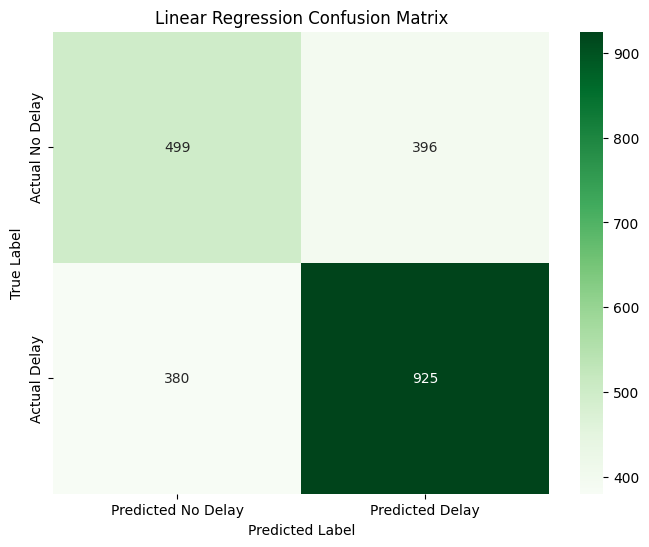

In [53]:
print("\nLinear Regression Model Performance (with 0.5 threshold for binary classification):")
print(f"Accuracy: {accuracy_lin_reg:.4f}")
print(f"Precision: {precision_lin_reg:.4f}")
print(f"Recall: {recall_lin_reg:.4f}")
print(f"F1-Score: {f1_lin_reg:.4f}")
print("Confusion Matrix:\n", conf_matrix_lin_reg)

import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Confusion Matrix for Linear Regression
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lin_reg, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted No Delay', 'Predicted Delay'],
            yticklabels=['Actual No Delay', 'Actual Delay'])
plt.title('Linear Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [54]:
print("\nLinear Regression Model Performance (with 0.5 threshold for binary classification):")
print(f"Accuracy: {accuracy_lin_reg:.4f}")
print(f"Precision: {precision_lin_reg:.4f}")
print(f"Recall: {recall_lin_reg:.4f}")
print(f"F1-Score: {f1_lin_reg:.4f}")
print(f"R-squared: {r2_lin_reg:.4f}")
print("Confusion Matrix:\n", conf_matrix_lin_reg)



Linear Regression Model Performance (with 0.5 threshold for binary classification):
Accuracy: 0.6473
Precision: 0.7002
Recall: 0.7088
F1-Score: 0.7045
R-squared: 0.1850
Confusion Matrix:
 [[499 396]
 [380 925]]


In [55]:
import joblib

# Define the filename for the saved model
model_filename = 'logistic_regression_model.sav'

# Save the trained Logistic Regression model to a .sav file
joblib.dump(log_reg_model, model_filename)

print(f"Logistic Regression model saved to '{model_filename}'")

Logistic Regression model saved to 'logistic_regression_model.sav'
